# MLOps Assignment: Predictive Maintenance Classification

**Submitted by: Tunir Saha**

### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [1]:
# Adding a cell here to keep all the pip installation libraries in one place

!pip install pandas numpy matplotlib seaborn pandera mlflow xgboost lightgbm optuna imblearn evidently shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.5/442.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.0/270.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('data/train.csv')
current = pd.read_csv('data/current.csv')
stress  = pd.read_csv('data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [3]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    'Type':                Column(str,     Check.isin(['L', 'M', 'H'])),
    'Air temperature':     Column(float,   Check.in_range(295.0, 305.0)),
    'Process temperature': Column(float,   Check.in_range(305.0, 315.0)),
    'Rotational speed':    Column('int64', Check.in_range(1000, 2900)),
    'Torque':              Column(float,   Check.in_range(3.0, 80.0)),
    'Tool wear':           Column('int64', Check.in_range(0, 253)),
    'Failure_Type':        Column('int64', Check.isin([0, 1, 2, 3, 4])),
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
schema.validate(current)
print('train   : schema validation PASSED')
print('current : schema validation PASSED')

# TODO: Validate stress with lazy=True and print violation summary
try:
    schema.validate(stress, lazy=True)
    print('stress  : schema validation PASSED  -> VALID data (drift is checked separately in Section 3)')
except pa.errors.SchemaErrors as e:
    print('stress  : schema violations found:')
    print(e.failure_cases.groupby('column').size())


train   : schema validation PASSED
current : schema validation PASSED
stress  : schema validation PASSED  -> VALID data (drift is checked separately in Section 3)


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Failure_Type distribution (imbalanced):
Failure_Type
0    6762
1      30
2      76
3      56
4      69
Name: count, dtype: int64

Minority share: 3.30%


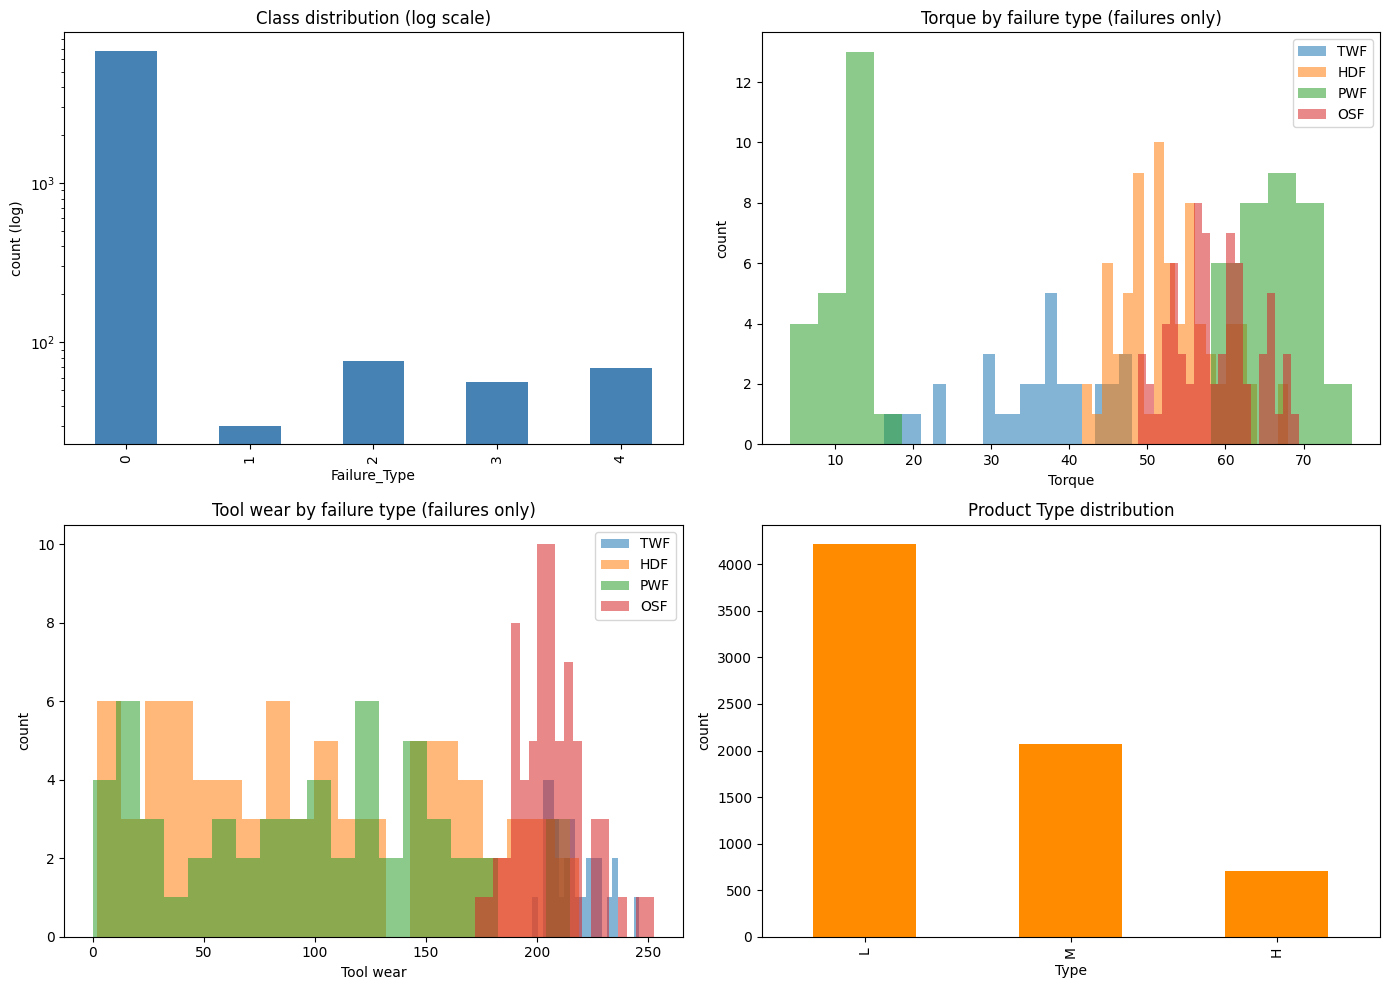

                   mean   min   max  count
Failure_Type                              
0             39.651316  12.7  68.9   6762
1             35.656667  16.2  48.0     30
2             52.997368  41.6  68.0     76
3             43.421429   4.2  76.2     56
4             58.540580  48.8  69.4     69


In [4]:
fail_names = {0: 'None', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}  # adjust to your label map
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO: Class distribution (print + bar chart)
cls = train['Failure_Type'].value_counts().sort_index()
print('Failure_Type distribution (imbalanced):')
print(cls)
print(f'\nMinority share: {(cls[1:].sum() / len(train)) * 100:.2f}%')
ax = axes[0, 0]
cls.plot(kind='bar', ax=ax, color='steelblue', logy=True)
ax.set_title('Class distribution (log scale)')
ax.set_xlabel('Failure_Type'); ax.set_ylabel('count (log)')

# failures only for next two
fail = train[train['Failure_Type'] != 0]

# TODO: Torque distribution by failure type (histogram, failures only)
ax = axes[0, 1]
for k in sorted(fail['Failure_Type'].unique()):
    ax.hist(fail.loc[fail['Failure_Type'] == k, 'Torque'], bins=20,
            alpha=0.55, label=fail_names.get(k, k))
ax.set_title('Torque by failure type (failures only)')
ax.set_xlabel('Torque'); ax.set_ylabel('count'); ax.legend()

# TODO: Tool wear distribution by failure type
ax = axes[1, 0]
for k in sorted(fail['Failure_Type'].unique()):
    ax.hist(fail.loc[fail['Failure_Type'] == k, 'Tool wear'], bins=20,
            alpha=0.55, label=fail_names.get(k, k))
ax.set_title('Tool wear by failure type (failures only)')
ax.set_xlabel('Tool wear'); ax.set_ylabel('count'); ax.legend()

# TODO: Type distribution
ax = axes[1, 1]
train['Type'].value_counts().reindex(['L', 'M', 'H']).plot(
    kind='bar', ax=ax, color='darkorange')
ax.set_title('Product Type distribution')
ax.set_xlabel('Type'); ax.set_ylabel('count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(train.groupby('Failure_Type')['Torque'].agg(['mean','min','max','count']))

### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [5]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W']   = df['Torque'] * (df['Rotational speed'] * 2 * np.pi / 60)
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
grouped = train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean()
grouped.index = [CLASS_NAMES[i] for i in grouped.index]
print('Mean engineered features by failure type:')
print(grouped.round(2))


Mean engineered features by failure type:
            Power_W  Temp_diff
No Failure  6248.24      10.01
TWF         5763.09       9.97
HDF         7403.55       8.23
PWF         6664.38       9.82
OSF         8216.07      10.07


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Train split:', X_tr.shape, '| Val split:', X_val.shape)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
sm = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = sm.fit_resample(X_tr, y_tr)

# TODO: Print post-SMOTE class distribution
print('\nPre-SMOTE  (train) :', y_tr.value_counts().sort_index().to_dict())
print('Post-SMOTE (train) :', pd.Series(y_res).value_counts().sort_index().to_dict())
print('Validation (untouched):', y_val.value_counts().sort_index().to_dict())


Train split: (5594, 8) | Val split: (1399, 8)

Pre-SMOTE  (train) : {0: 5409, 1: 24, 2: 61, 3: 45, 4: 55}
Post-SMOTE (train) : {0: 5409, 1: 5409, 2: 5409, 3: 5409, 4: 5409}
Validation (untouched): {0: 1353, 1: 6, 2: 15, 3: 11, 4: 14}


*Your explanation here: why is SMOTE applied only on the training split?*

**Answer:** SMOTE creates fake minority samples by interpolating between real ones that sit close together. So if I'd oversampled before splitting, a synthetic point could end up in training while the real neighbor it was built from lands in validation. The model would basically be tested on echoes of its own training data, and the scores would look better than they are. Splitting first avoids that.

The other reason is that validation should look like the real world. In production the model sees roughly 97% No-Failure cases — that imbalance is the actual problem, not something to paper over. If I balanced the validation set too, I'd be grading the model on a tidy 5-way split it never actually encounters. Leaving it untouched (0:1353, 1:6, … 4:14) keeps the estimate honest, which is also why I'm scoring with macro-F1: it gives every rare class equal weight even though they barely show up.

Put simply, oversampling fixes the model's bias toward the majority class during training. It's not a fix to the data, so it has no business touching validation.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [7]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])
for name, model in models_to_run.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_res, y_res)
        pred = model.predict(X_val)

        macro_f1    = f1_score(y_val, pred, average='macro')
        weighted_f1 = f1_score(y_val, pred, average='weighted')
        acc         = accuracy_score(y_val, pred)
        per_class   = f1_score(y_val, pred, average=None, labels=CLASS_LIST)

        mlflow.log_param('model', name)
        mlflow.log_metric('macro_f1', macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('accuracy', acc)
        for c, fc in zip(CLASS_LIST, per_class):
            mlflow.log_metric(f'f1_class_{c}_{CLASS_NAMES[c]}', fc)

        mlflow.sklearn.log_model(
            model, name='model',
            input_example=X_val.iloc[:5],
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE)

        results[name] = {'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
                         'accuracy': acc,
                         **{f'f1_{CLASS_NAMES[c]}': fc
                            for c, fc in zip(CLASS_LIST, per_class)}}
    print(f'{name:20s} macro_f1={macro_f1:.4f}  weighted_f1={weighted_f1:.4f}  acc={acc:.4f}')

# TODO: Print comparison table
comparison = pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)
print('\n==== Model comparison (sorted by macro F1) ====')
print(comparison.round(4))

# TODO: Identify best model by macro F1
best_name = comparison['macro_f1'].idxmax()
print(f'\nBest model by macro F1: {best_name}  (macro_f1={comparison.loc[best_name, "macro_f1"]:.4f})')

2026/06/27 17:53:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/27 17:53:07 INFO mlflow.store.db.utils: Updating database tables
2026/06/27 17:53:10 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_ModelSelection' does not exist. Creating a new experiment.
2026/06/27 17:53:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression   macro_f1=0.5312  weighted_f1=0.9328  acc=0.9042


2026/06/27 17:53:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest         macro_f1=0.7355  weighted_f1=0.9855  acc=0.9850


2026/06/27 17:53:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost              macro_f1=0.7481  weighted_f1=0.9851  acc=0.9843


2026/06/27 17:53:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM             macro_f1=0.7296  weighted_f1=0.9851  acc=0.9843

==== Model comparison (sorted by macro F1) ====
                    macro_f1  weighted_f1  accuracy  f1_No Failure  f1_TWF  \
XGBoost               0.7481       0.9851    0.9843         0.9922  0.1333   
RandomForest          0.7355       0.9855    0.9850         0.9926  0.0000   
LightGBM              0.7296       0.9851    0.9843         0.9922  0.0000   
LogisticRegression    0.5312       0.9328    0.9042         0.9483  0.1449   

                    f1_HDF  f1_PWF  f1_OSF  
XGBoost             0.9655  0.8800  0.7692  
RandomForest        0.9286  0.9565  0.8000  
LightGBM            0.9655  0.8333  0.8571  
LogisticRegression  0.4545  0.4583  0.6500  

Best model by macro F1: XGBoost  (macro_f1=0.7481)


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [8]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)
    model.fit(X_res, y_res)
    pred = model.predict(X_val)
    return f1_score(y_val, pred, average='macro')

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize
study.optimize(objective, n_trials=30, show_progress_bar=True)
best_params = {**study.best_params,
               'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0}
print(f'\nBest trial macro_f1 = {study.best_value:.4f}')
print('Best params:', best_params)

# TODO: Train final best model
final_model = XGBClassifier(**best_params)
final_model.fit(X_res, y_res)
tuned_pred  = final_model.predict(X_val)
tuned_macro = f1_score(y_val, tuned_pred, average='macro')
print(f'Final model macro_f1 on val = {tuned_macro:.4f}')

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
from mlflow.tracking import MlflowClient
with mlflow.start_run(run_name='XGBoost_optuna_best'):
    mlflow.log_params(best_params)
    mlflow.log_metric('macro_f1', tuned_macro)
    mlflow.sklearn.log_model(
        final_model, name='model',
        input_example=X_val.iloc[:5],
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        registered_model_name='PredMaint_XGBoost')

client   = MlflowClient()
versions = client.search_model_versions("name='PredMaint_XGBoost'")
latest   = max(int(v.version) for v in versions)
client.set_registered_model_alias('PredMaint_XGBoost', 'production', latest)
print(f"Registered PredMaint_XGBoost v{latest} -> alias 'production'")

# TODO: Save with joblib.dump
joblib.dump(final_model, 'best_model.pkl')
print('Saved best_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print('Saved label_encoder.pkl')

2026/06/27 17:53:54 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_Optuna' does not exist. Creating a new experiment.


  0%|          | 0/30 [00:00<?, ?it/s]


Best trial macro_f1 = 0.7705
Best params: {'n_estimators': 429, 'max_depth': 6, 'learning_rate': 0.04229592447725514, 'min_child_weight': 5.62386466802396, 'subsample': 0.8353730606262738, 'colsample_bytree': 0.9404978657287971, 'gamma': 1.343863203456621, 'reg_alpha': 9.261293971713549e-06, 'reg_lambda': 6.786935263363131e-07, 'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0}


2026/06/27 17:55:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final model macro_f1 on val = 0.7705
Registered PredMaint_XGBoost v1 -> alias 'production'
Saved best_model.pkl
Saved label_encoder.pkl


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [9]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary
print('Mean Rotational speed -> train: {:.1f} | current: {:.1f} | stress: {:.1f}'.format(
    train['Rotational speed'].mean(), current['Rotational speed'].mean(),
    stress['Rotational speed'].mean()))

report_current = Report(metrics=[DataDriftPreset()])
report_current.run(reference_data=train[FEAT_COLS], current_data=current[FEAT_COLS])
report_current.save_html('drift_current.html')

res = report_current.as_dict()['metrics'][0]['result']
print('\n==== current.csv drift summary ====')
print('Dataset drift detected :', res['dataset_drift'])
print('Drifted features       : {} / {}'.format(
    res['number_of_drifted_columns'], res['number_of_columns']))
print('Share of drifted columns:', round(res['share_of_drifted_columns'], 3))
print('Saved -> drift_current.html')


Mean Rotational speed -> train: 1539.0 | current: 1530.2 | stress: 1497.1

==== current.csv drift summary ====
Dataset drift detected : False
Drifted features       : 0 / 5
Share of drifted columns: 0.0
Saved -> drift_current.html


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [10]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics
report_stress = Report(metrics=[
    DatasetDriftMetric(),
    *[ColumnDriftMetric(column_name=c) for c in FEAT_COLS],
])
report_stress.run(reference_data=train[FEAT_COLS], current_data=stress[FEAT_COLS])

# TODO: Save drift_stress.html
report_stress.save_html('drift_stress.html')
print('Saved -> drift_stress.html')

# TODO: Print per-column drift table
metrics = report_stress.as_dict()['metrics']

ds = metrics[0]['result']
print('\n==== stress.csv drift summary ====')
print('Dataset drift detected :', ds['dataset_drift'])
print('Drifted features       : {} / {}'.format(
    ds['number_of_drifted_columns'], ds['number_of_columns']))

rows = []
for m in metrics[1:]:
    r = m['result']
    col      = r['column_name']
    ref_mean = train[col].mean()
    cur_mean = stress[col].mean()
    rows.append({'feature': col,
                 'drift_detected': r['drift_detected'],
                 'wasserstein_score': round(r['drift_score'], 4),
                 'ref_mean': round(ref_mean, 2),
                 'current_mean': round(cur_mean, 2),
                 'delta': round(cur_mean - ref_mean, 2)})
drift_table = pd.DataFrame(rows).sort_values('wasserstein_score')
print('\n==== per-column drift (stress vs train) ====')
print(drift_table.to_string(index=False))


Saved -> drift_stress.html

==== stress.csv drift summary ====
Dataset drift detected : True
Drifted features       : 3 / 5

==== per-column drift (stress vs train) ====
            feature  drift_detected  wasserstein_score  ref_mean  current_mean  delta
    Air temperature           False             0.0344    300.01        300.05   0.04
Process temperature           False             0.0377    310.00        310.01   0.00
   Rotational speed            True             0.2354   1539.02       1497.07 -41.94
             Torque            True             0.4739     40.00         44.72   4.73
          Tool wear            True             0.6455    107.68        148.87  41.19


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: Three of the five features drifted in the stress batch: Rotational speed (0.235), Torque (0.474), and Tool wear (0.655). I'm reading the normed Wasserstein distances from 3.2 against the default 0.1 threshold. Air and Process temperature stayed put (0.034 and 0.038), so they don't count as drift. Worth noting that 3.1 found zero drift in current.csv, which tells me this shift is real and specific to the stress conditions, not something my pipeline introduced.

2. Most likely failure type to increase: OSF (Overstrain Failure) - The two features that drifted hardest, Tool wear and Torque, are the same two that physically cause overstrain, since OSF fires when tool wear times torque crosses a strain limit. That lines up with what I saw earlier: in 1.4, OSF had the highest mean power (8216 W), and its samples sit at high tool wear (roughly 180 to 220) and high torque. When both of those inputs drift upward, more parts cross the OSF line. My SHAP results in Section 4 back this up, with Torque and Tool wear sitting near the top of the OSF attributions. PWF is the next thing I'd watch, since Torque feeds power failures too.

3. Retraining recommendation: Retrain. The case rests on three findings that point the same direction. Section 3.2 flags dataset drift as True, and the drift sits in the features the model actually leans on rather than in noise like temperature. Section 4 shows those exact features driving the failure predictions, so the drift hits the model where it's most sensitive. And 3.1 confirms the model is still fine on normal traffic, so this isn't a blanket reset, it's a fix for the stress regime specifically.

  The chain, end to end: Tool wear and Torque drift in 3.2, those features dominate the OSF and PWF SHAP attributions in Section 4, a model trained on the calmer pre-stress data will undercount OSF, so I retrain on data that includes the stressed distribution before trusting it in that regime.


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

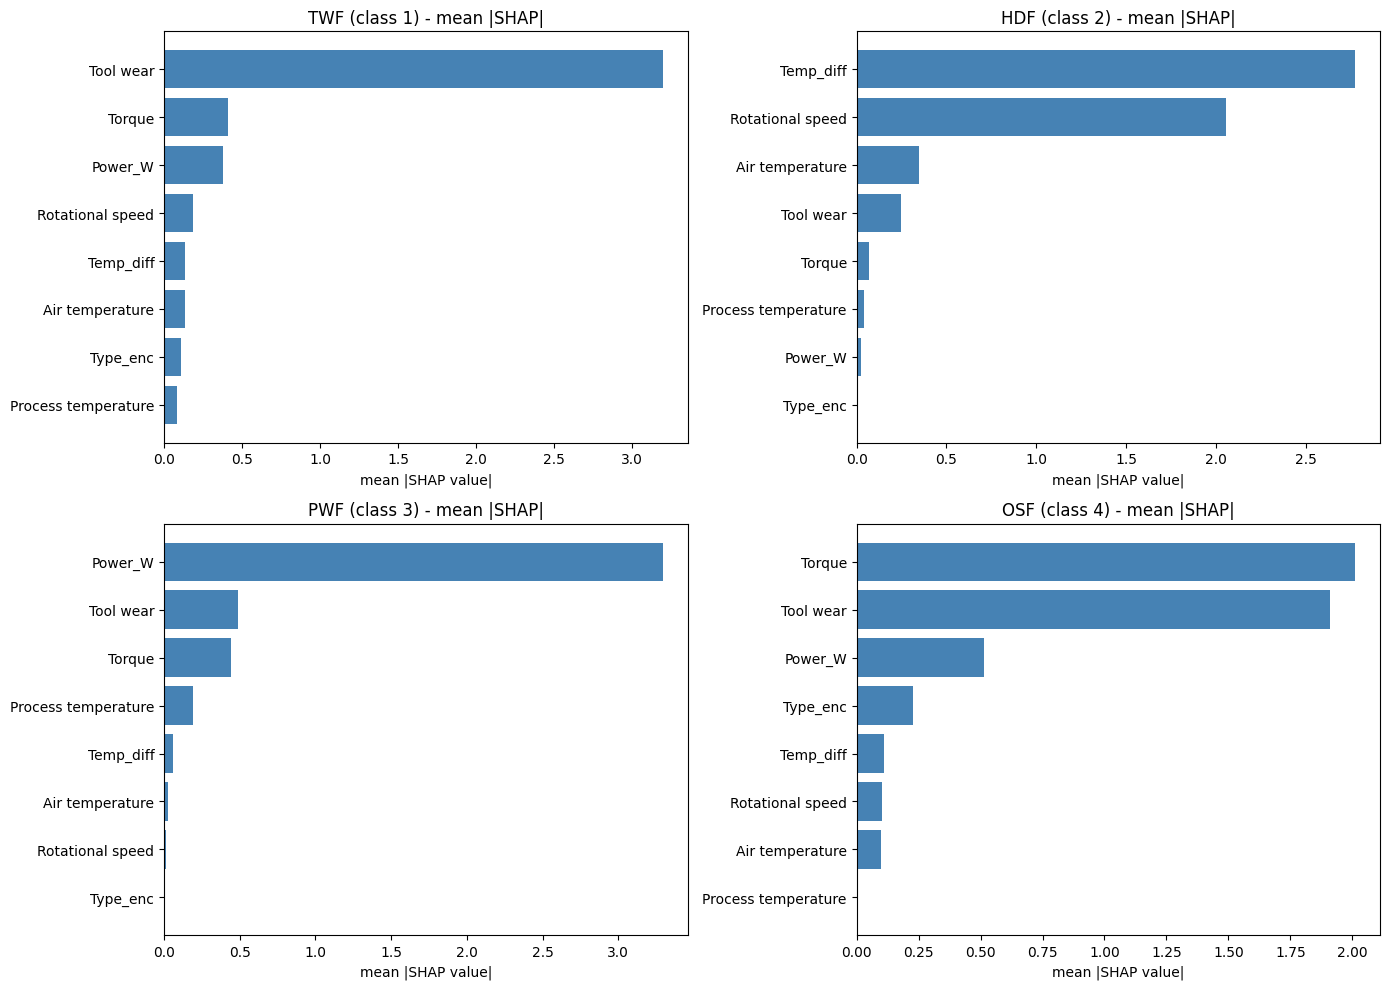

Top SHAP driver per failure class:
  TWF          (class 1): Tool wear
  HDF          (class 2): Temp_diff
  PWF          (class 3): Power_W
  OSF          (class 4): Torque


In [11]:
import shap

best_model = joblib.load('best_model.pkl')

# TODO: Compute SHAP values using TreeExplainer
explainer   = shap.TreeExplainer(best_model)
shap_vals   = explainer.shap_values(train[FEATURES])

# normalize shape -> list of (n_samples, n_features), one per class
if isinstance(shap_vals, list):
    shap_by_class = shap_vals                      # older shap: list per class
else:
    shap_by_class = [shap_vals[:, :, k] for k in range(shap_vals.shape[2])]  # (n,f,c)

features      = FEATURES
failure_codes = [1, 2, 3, 4]                        # 4 failure classes, skip No-Failure

# TODO: Plot 4-subplot bar chart (one per failure class)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, k in zip(axes.ravel(), failure_codes):
    mean_abs = np.abs(shap_by_class[k]).mean(axis=0)
    order    = np.argsort(mean_abs)
    ax.barh([features[i] for i in order], mean_abs[order], color='steelblue')
    ax.set_title(f'{CLASS_NAMES[k]} (class {k}) - mean |SHAP|')
    ax.set_xlabel('mean |SHAP value|')

plt.tight_layout()

# TODO: Save shap_per_class.png
plt.savefig('shap_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: Print top driver per class
print('Top SHAP driver per failure class:')
for k in failure_codes:
    mean_abs = np.abs(shap_by_class[k]).mean(axis=0)
    top      = features[int(np.argmax(mean_abs))]
    print(f'  {CLASS_NAMES[k]:12s} (class {k}): {top}')


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: Power_W runs the PWF prediction almost on its own, mean |SHAP| around 3.25, while raw Torque (~0.43) and Rotational speed (close to zero) barely move the needle. That tracks with the physics: power failure depends on torque times speed, not either one alone, so the model reads the interaction straight off Power_W rather than rebuilding it from two raw columns. The engineered feature earned its place here.

2. Temp_diff for HDF: Temp_diff is the strongest driver for HDF (mean |SHAP| ~2.8) and goes quiet everywhere else, sitting near the bottom for TWF, PWF, and OSF. That narrow spike is the point. Heat dissipation failure is defined by a small process-to-air temperature gap, so the feature encoding that gap matters for HDF and nowhere else.

3. Physical mechanisms:
3.1. TWF (tool wear failure): Tool wear leads by a long way (\~3.25 against \~0.4 for the rest). The tool degrades with cumulative use until it gives out, and load or temperature hardly enter into it.
3.2. HDF (heat dissipation failure): Temp_diff and Rotational speed lead. A small temperature gap plus a slow-turning spindle means the machine can't shed heat fast enough, and it overheats.
3.3. PWF (power failure): Power_W is far ahead. Power is torque times speed, and the part fails when that product leaves the machine's operating band, at the low or the high end.
3.4. OSF (overstrain failure): Torque and Tool wear share the top spot (~2.0 and ~1.9). A worn tool under heavy torque crosses the strain limit, so the two multiply together to break it.


## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
Tuned XGBoost won with macro F1 = 0.7705, ahead of the field: baseline XGBoost 0.7481, RandomForest 0.7355, LightGBM 0.7296, and LogisticRegression far back at 0.5312. Optuna (30 TPE trials optimising macro F1) lifted XGBoost from 0.7481 to 0.7705, a +0.022 gain. The tuned model was registered as PredMaint_XGBoost and promoted to the production alias. I picked on macro F1, which weights every class equally, not on accuracy.

**2. Accuracy vs Macro F1:**
 The data is about 96.7% "No Failure", roughly a 225:1 imbalance. A lazy model that always predicts "No Failure" scores ~0.97 accuracy and catches zero actual failures, which tanks its macro F1. The expensive mistakes here are missed failures, so accuracy (0.984) just hides the blind spot. Macro F1 exposes per-class recall on the rare failure types, so it's the only honest selection metric.

**3. The TWF problem:**
TWF F1 sits near 0.13 even after SMOTE (k_neighbors=3) and Optuna. The root cause is data, not the model: only 30 real TWF samples exist (about 0.43%), roughly 24 in train and 6 in validation. SMOTE interpolates between those few points but can't invent new failure physics, so the class stays effectively unlearnable. The fix is collecting more real TWF events through targeted logging around high tool wear, not more tuning. The ceiling is the data, not the hyperparameters.

**4. Drift and maintenance schedule:**
current.csv was stable (0/5 features drifted). stress.csv flagged dataset drift = True with 3/5 features shifted: Tool wear, Torque, and Rotational speed (which dropped ~42 rpm, from 1539 to 1497), while both temperatures held steady. Heavy-load periods push the machines into a high-wear, high-torque regime that's under-represented in training, which raises OSF and TWF risk. Maintenance should move from fixed-interval to condition-based, triggered by this drift signature, with tighter inspection cycles during stress periods.

**5. Actionable recommendation:**
Use this format: Condition -> Risked failure class -> Action.
- Condition: Tool wear climbing past ~150 min while Torque sits above ~45 Nm, the regime the stress batch drifted into.
- Risked class: OSF (overstrain), since Torque and Tool wear are its top SHAP drivers, with TWF rising alongside.
- Action: add an automated drift gate on Tool wear and Torque. When it trips, schedule preventive tool replacement and cap torque/feed-rate, then retrain on the freshly collected high-load data before redeploying.